<a href="https://colab.research.google.com/github/hkrishnanrt/DSA-Activities/blob/main/Data_Preprocessing_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


Dataset overview

In [133]:
data=pd.read_csv('/content/House_Pricing.csv')
df=pd.DataFrame(data)
df

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,...,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,...,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,...,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,...,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [135]:
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


Duplicate Removal

In [136]:
df.drop_duplicates(inplace=True)

Handling Missing Values

In [137]:
df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [138]:
df.drop(columns={'No of Times Visited'},inplace=True)

array([[<Axes: title={'center': 'Sale Price'}>,
        <Axes: title={'center': 'No of Bathrooms'}>,
        <Axes: title={'center': 'Flat Area (in Sqft)'}>],
       [<Axes: title={'center': 'Lot Area (in Sqft)'}>,
        <Axes: title={'center': 'No of Floors'}>,
        <Axes: title={'center': 'Area of the House from Basement (in Sqft)'}>],
       [<Axes: title={'center': 'Zipcode'}>,
        <Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>],
       [<Axes: title={'center': 'Living Area after Renovation (in Sqft)'}>,
        <Axes: >, <Axes: >]], dtype=object)

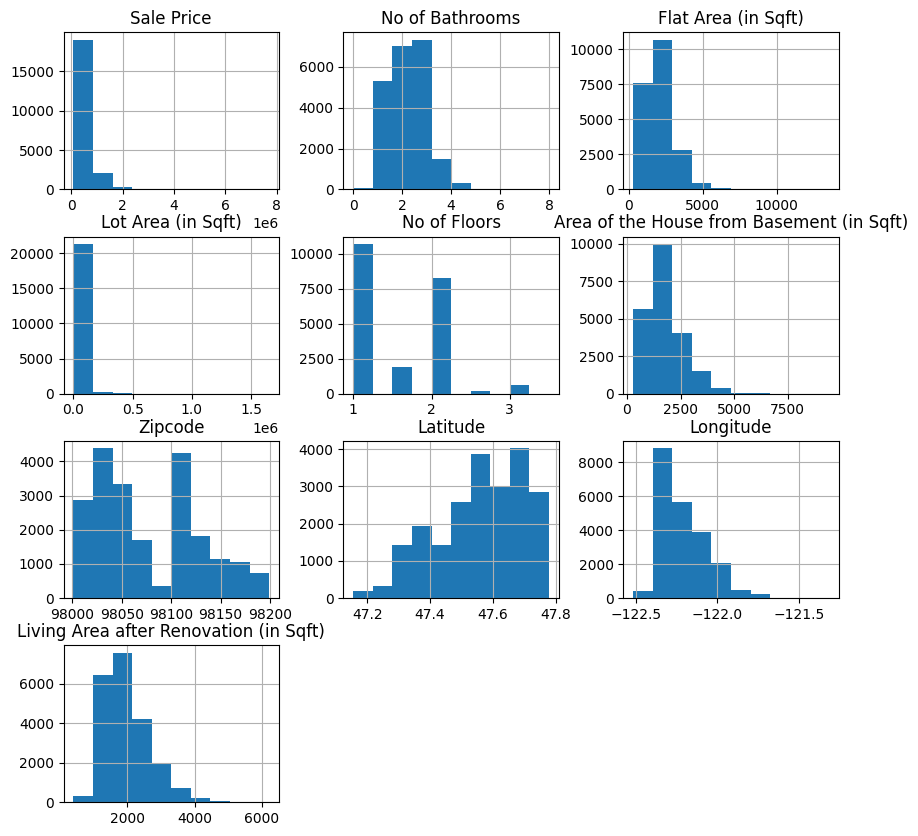

In [139]:
num_cols=df.select_dtypes(include='float64')
num_cols.hist(figsize=(10,10))

In [140]:
num_cols=['Sale Price',
'Flat Area (in Sqft)',
'Lot Area (in Sqft)',
'No of Floors',
'Area of the House from Basement (in Sqft)',
'Living Area after Renovation (in Sqft)']
df.fillna({col : df[col].median() for col in num_cols},inplace=True)

In [141]:
df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


In [142]:
df.fillna({'Zipcode' : df['Zipcode'].mode()[0]},inplace=True)
df.fillna({'Latitude' : df['Latitude'].mode()[0]},inplace=True)
df.fillna({'Longitude' : df['Longitude'].mode()[0]},inplace=True)
df.fillna({'No of Bathrooms' : df['No of Bathrooms'].mode()[0]},inplace=True)

In [143]:
df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0



Scaling Numerical Variables

In [144]:
df.select_dtypes(include='float64')

,Sale Price,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Area of the House from Basement (in Sqft),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft)
0,221900.0,1.00,1180.0,5650.0,1.0,1180.0,98178.0,47.5112,-122.257,1340.0
1,538000.0,2.25,2570.0,7242.0,2.0,2170.0,98125.0,47.7210,-122.319,1690.0
2,180000.0,1.00,770.0,10000.0,1.0,770.0,98028.0,47.7379,-122.233,2720.0
3,604000.0,3.00,1960.0,5000.0,1.0,1050.0,98136.0,47.5208,-122.393,1360.0
4,510000.0,2.00,1680.0,8080.0,1.0,1680.0,98074.0,47.6168,-122.045,1800.0
...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,2.50,1530.0,1131.0,3.0,1530.0,98103.0,47.6993,-122.346,1530.0
21609,400000.0,2.50,2310.0,5813.0,2.0,2310.0,98146.0,47.5107,-122.362,1830.0
21610,402101.0,0.75,1020.0,1350.0,2.0,1020.0,98144.0,47.5944,-122.299,1020.0
21611,400000.0,2.50,1600.0,2388.0,2.0,1600.0,98027.0,47.5345,-122.069,1410.0


In [145]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

std_scaler=StandardScaler()
min_scaler=MinMaxScaler()

cols=[
      'Flat Area (in Sqft)',
      'Lot Area (in Sqft)',
      'Area of the House from Basement (in Sqft)',
      'Living Area after Renovation (in Sqft)']
df[cols]=min_scaler.fit_transform(df[cols])

In [146]:
df

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,0.067170,0.003108,1.0,No,Fair,7,0.097588,0,63,0,98178.0,47.5112,-122.257,0.161934,5650
1,6414100192,14 December 2017,538000.0,3,2.25,0.172075,0.004072,2.0,No,Fair,7,0.206140,400,67,1991,98125.0,47.7210,-122.319,0.222165,7639
2,5631500400,15 February 2016,180000.0,2,1.00,0.036226,0.005743,1.0,No,Fair,6,0.052632,0,85,0,98028.0,47.7379,-122.233,0.399415,8062
3,2487200875,14 December 2017,604000.0,4,3.00,0.126038,0.002714,1.0,No,Excellent,7,0.083333,910,53,0,98136.0,47.5208,-122.393,0.165376,5000
4,1954400510,15 February 2016,510000.0,3,2.00,0.104906,0.004579,1.0,No,Fair,8,0.152412,0,31,0,98074.0,47.6168,-122.045,0.241094,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,0.093585,0.000370,3.0,No,Fair,8,0.135965,0,9,0,98103.0,47.6993,-122.346,0.194631,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,0.152453,0.003206,2.0,No,Fair,8,0.221491,0,4,0,98146.0,47.5107,-122.362,0.246257,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,0.055094,0.000503,2.0,No,Fair,7,0.080044,0,9,0,98144.0,47.5944,-122.299,0.106866,2007
21611,291310100,15 January 2016,400000.0,3,2.50,0.098868,0.001132,2.0,No,Fair,8,0.143640,0,14,0,98027.0,47.5345,-122.069,0.173980,1287


In [147]:
df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


Encoding Categorical Variables

In [148]:
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder

label_enc=LabelEncoder()

df['Overall Grade_enc']=label_enc.fit_transform(df['Overall Grade'])
df['Condition of the House_enc']=label_enc.fit_transform(df['Condition of the House'])

pd.get_dummies(df,columns=['Waterfront View'],
                prefix='Wv',
                dtype='int64'
                              )

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Condition of the House,Overall Grade,...,Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Overall Grade_enc,Condition of the House_enc,Wv_No,Wv_Yes
0,7129300520,14 October 2017,221900.0,3,1.00,0.067170,0.003108,1.0,Fair,7,...,0,98178.0,47.5112,-122.257,0.161934,5650,6,2,1,0
1,6414100192,14 December 2017,538000.0,3,2.25,0.172075,0.004072,2.0,Fair,7,...,1991,98125.0,47.7210,-122.319,0.222165,7639,6,2,1,0
2,5631500400,15 February 2016,180000.0,2,1.00,0.036226,0.005743,1.0,Fair,6,...,0,98028.0,47.7379,-122.233,0.399415,8062,5,2,1,0
3,2487200875,14 December 2017,604000.0,4,3.00,0.126038,0.002714,1.0,Excellent,7,...,0,98136.0,47.5208,-122.393,0.165376,5000,6,1,1,0
4,1954400510,15 February 2016,510000.0,3,2.00,0.104906,0.004579,1.0,Fair,8,...,0,98074.0,47.6168,-122.045,0.241094,7503,7,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,0.093585,0.000370,3.0,Fair,8,...,0,98103.0,47.6993,-122.346,0.194631,1509,7,2,1,0
21609,6600060120,15 February 2016,400000.0,4,2.50,0.152453,0.003206,2.0,Fair,8,...,0,98146.0,47.5107,-122.362,0.246257,7200,7,2,1,0
21610,1523300141,14 June 2017,402101.0,2,0.75,0.055094,0.000503,2.0,Fair,7,...,0,98144.0,47.5944,-122.299,0.106866,2007,6,2,1,0
21611,291310100,15 January 2016,400000.0,3,2.50,0.098868,0.001132,2.0,Fair,8,...,0,98027.0,47.5345,-122.069,0.173980,1287,7,2,1,0


Outlier Removal

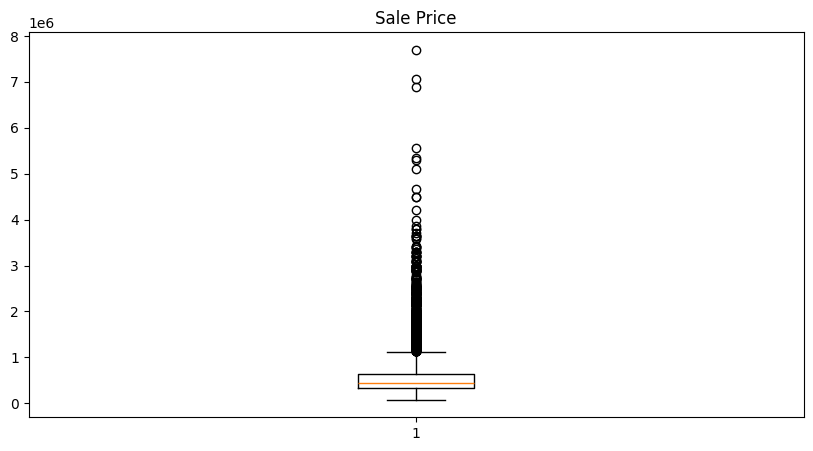

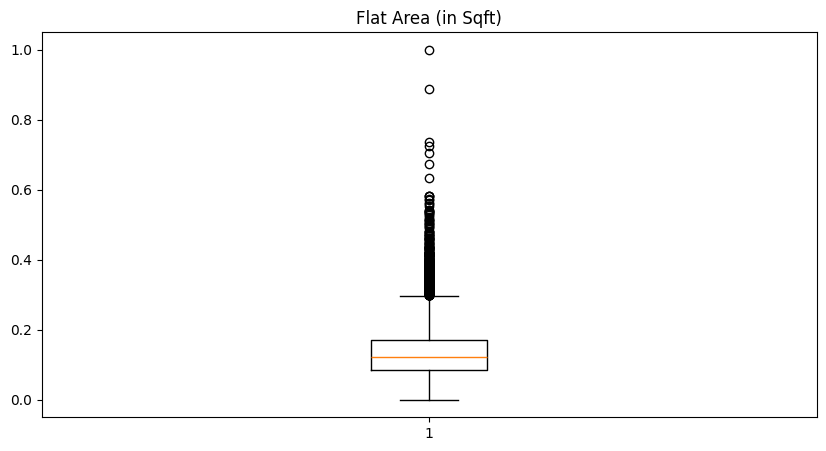

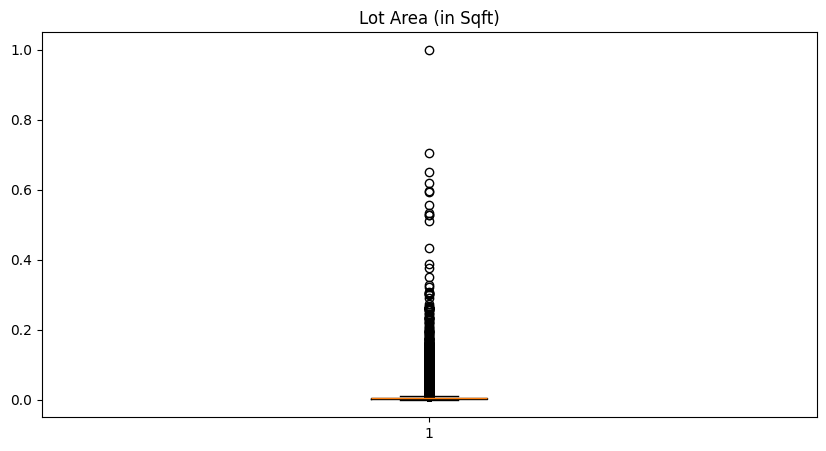

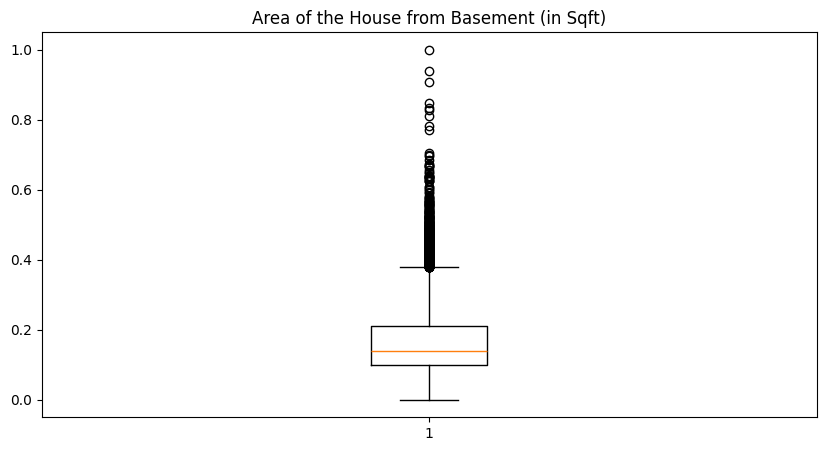

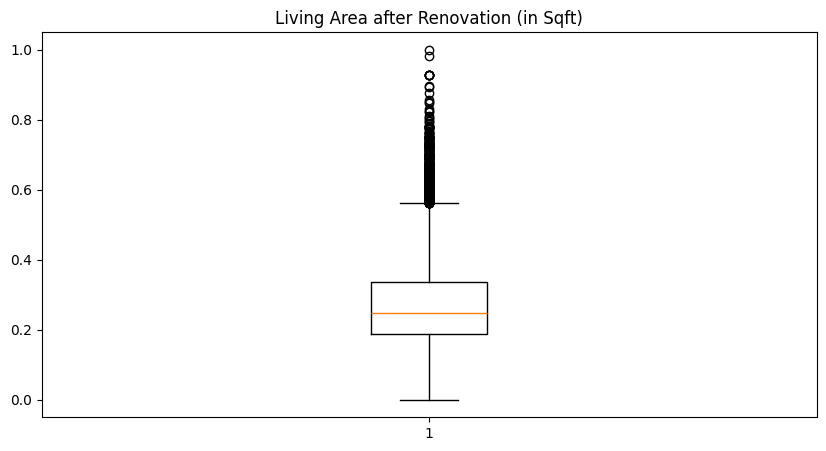

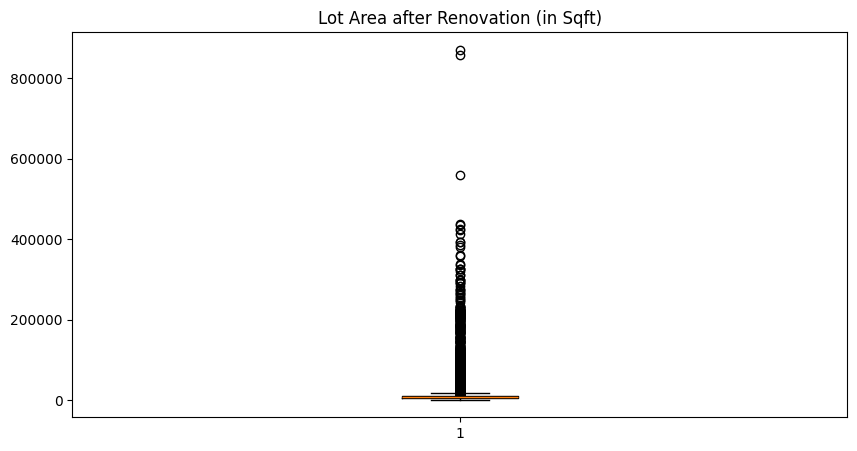

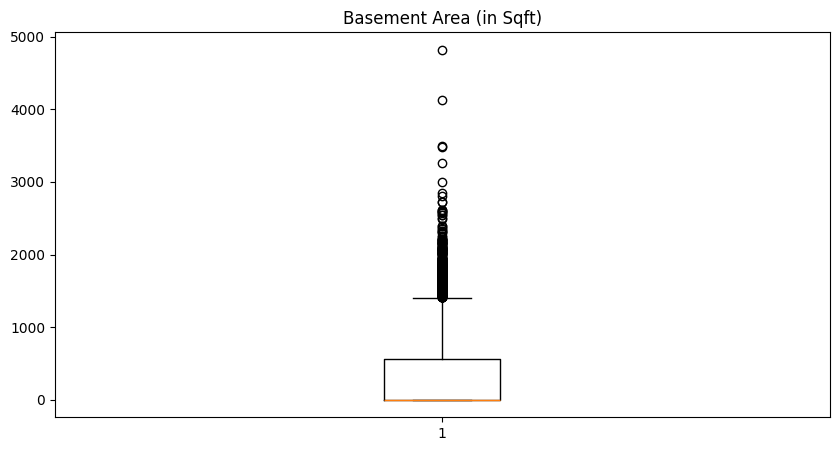

In [152]:
outlier_cols=['Sale Price',
'Flat Area (in Sqft)',
'Lot Area (in Sqft)',
'Area of the House from Basement (in Sqft)',
'Living Area after Renovation (in Sqft)','Lot Area after Renovation (in Sqft)','Basement Area (in Sqft)']
for i in  outlier_cols:
  plt.figure(figsize=(10,5))
  plt.boxplot(df[i])
  plt.title(i)


Column: Sale Price
Higher bound: 1129500.0
Lower bound: -162500.0
IQR: 323000.0
No. of outliers: 1159


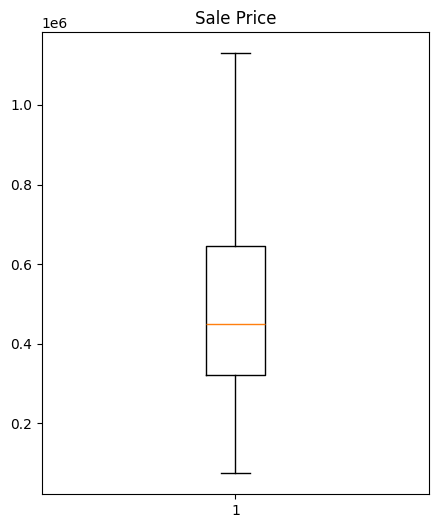


Column: Flat Area (in Sqft)
Higher bound: 0.2973584905660378
Lower bound: -0.04075471698113209
IQR: 0.08452830188679247
No. of outliers: 572


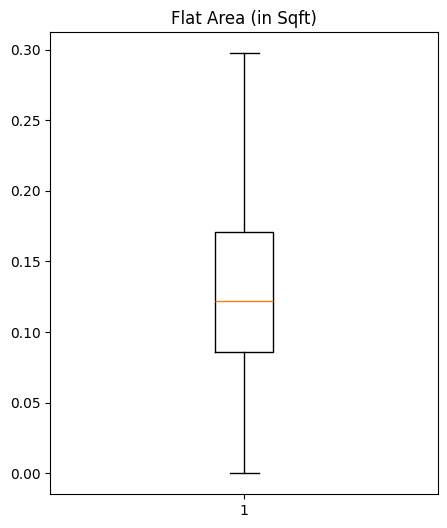


Column: Lot Area (in Sqft)
Higher bound: 0.011286685134043961
Lower bound: -0.002391208349209099
IQR: 0.0034194733708132648
No. of outliers: 2423


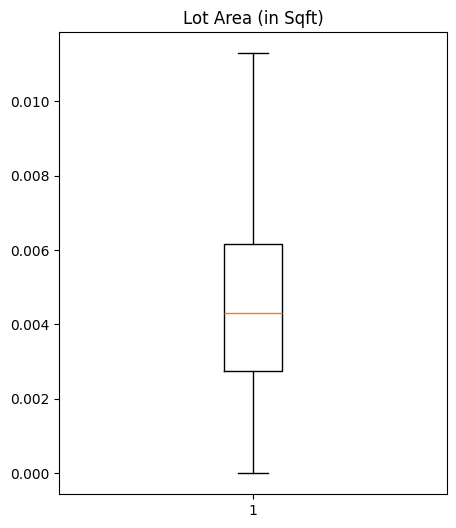


Column: Area of the House from Basement (in Sqft)
Higher bound: 0.3782894736842105
Lower bound: -0.06907894736842106
IQR: 0.1118421052631579
No. of outliers: 610


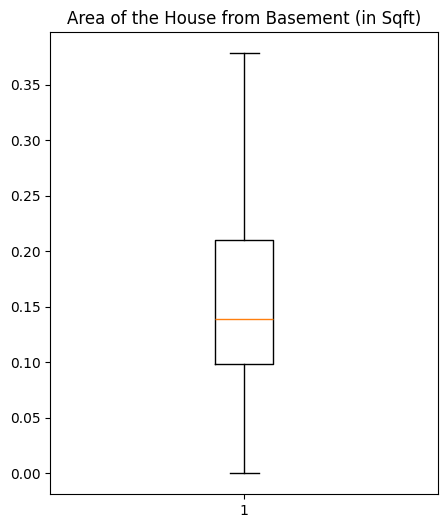


Column: Living Area after Renovation (in Sqft)
Higher bound: 0.5620375150576493
Lower bound: -0.036826707967647476
IQR: 0.14971605575632418
No. of outliers: 544


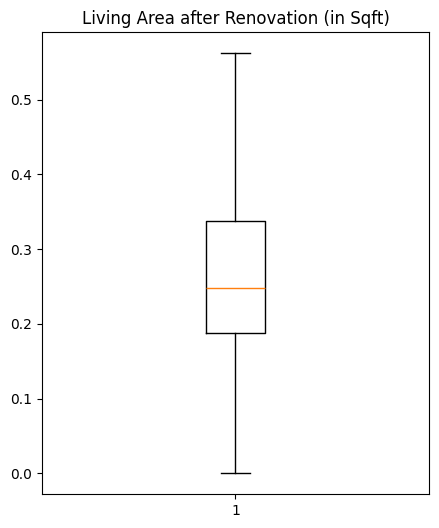


Column: Lot Area after Renovation (in Sqft)
Higher bound: 17557.5
Lower bound: -2374.5
IQR: 4983.0
No. of outliers: 2194


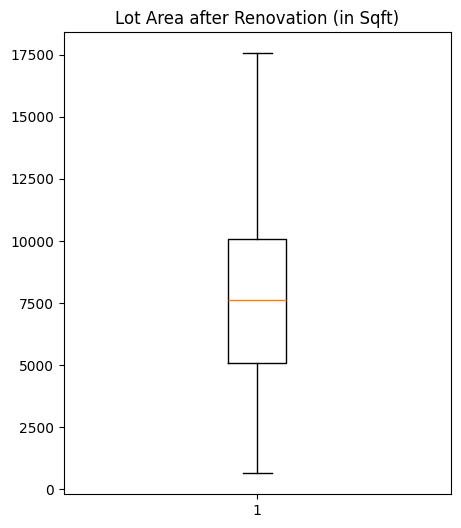


Column: Basement Area (in Sqft)
Higher bound: 1400.0
Lower bound: -840.0
IQR: 560.0
No. of outliers: 496


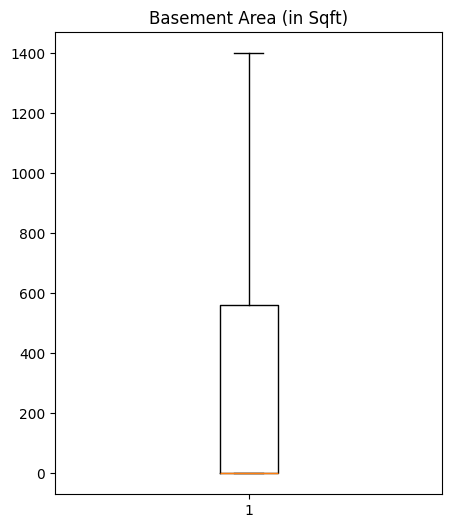

In [153]:
for col in outlier_cols:
    # 1. IQR bounds
    q1 = np.quantile(df[col], 0.25)
    q2 = np.quantile(df[col], 0.75)
    iqr = q2 - q1
    upb = q2 + (1.5 * iqr)
    lwb = q1 - (1.5 * iqr)

    print(f"\nColumn: {col}")
    print("Higher bound:", upb)
    print("Lower bound:", lwb)
    print("IQR:", iqr)

    # 2. Collect outliers
    outliers = [x for x in df[col] if x > upb or x < lwb]
    print("No. of outliers:", len(outliers))

    # 3. Clip values
    df[col] = df[col].clip(lower=lwb, upper=upb)

    # 4. Boxplot (optional, can skip if too many)
    plt.figure(figsize=(5,6))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

Train-Test Split

In [157]:
from sklearn.model_selection import train_test_split

X=df.drop('Sale Price',axis=1)
y=df['Sale Price']
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,
    random_state=42
)
print('Training set:',X_train.shape,y_train.shape)
print('Testing set:',X_test.shape,y_test.shape)

Training set: (17290, 21) (17290,)
Testing set: (4323, 21) (4323,)
